In [2]:
import pandas as pd

df = pd.read_csv("/Users/shwetakohale/Downloads/email.csv")

In [3]:
import re
import nltk

from nltk.stem import WordNetLemmatizer

In [4]:
lemmatizer = WordNetLemmatizer()

In [5]:
corpus = []
for i in range(0, len(df)):
    review = re.sub("[^a-zA-z]", " ", df['Message'][i])
    review = review.lower()
    review = review.split()

    new_review = []

    from nltk.corpus import stopwords
    
    for word in review:
                if not word in stopwords.words('english'):
                    review = lemmatizer.lemmatize(word)
                    new_review.append(review)
    review = ' '.join(new_review)
    corpus.append(review)
    

In [6]:
# print(len(corpus))
# print(corpus[:5])

In [7]:
##TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
cv = TfidfVectorizer()
X = cv.fit_transform(corpus).toarray()

In [8]:
conversion = pd.get_dummies(df['Category'])
conversion = conversion.iloc[:,1].values #defined that 0 -> ham and 1 -> spam


In [9]:
#Testing the model

from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, conversion,test_size = 0.2, random_state = 0)

In [10]:
#Naive Bayes
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [11]:
test_msg = input("Enter the message you want to check for spam: ").lower()
test_msg = cv.transform([test_msg]).toarray()

prediction = model.predict(test_msg)

print(" ")

if(prediction[0]==1):
    print("Output: Spam:(")
else:
    print("Output: Ham!")
    



Enter the message you want to check for spam:  hi my name is lola


 
Output: Ham!


#### Model Evaluation


In [12]:
#Accuracy Score

from sklearn.metrics import accuracy_score

#accuracy score on training data

X_train_predict = model.predict(X_train)
training_data_accuracy = accuracy_score(y_train, X_train_predict)
print(training_data_accuracy)


0.9775684163301929


In [13]:
print("Accuracy score on training data : ", round(training_data_accuracy*100, 2), "%")

Accuracy score on training data :  97.76 %


In [17]:
#accuracy on test data

X_test_predict = model.predict(X_test)
test_data_accuracy = accuracy_score(y_test, X_test_predict)
print(test_data_accuracy)

0.9739910313901345


In [15]:
print("Accuracy score on test data : ", round(trainin_data_accuracy*100, 2), "%")

Accuracy score on test data :  97.4 %


In [18]:
#Confusion matrix

from sklearn.metrics import confusion_matrix

cf_matrix = confusion_matrix(y_test, X_test_predict)
print(cf_matrix)

[[966   0]
 [ 29 120]]


In [19]:
tn, fp, fn, tp = cf_matrix.ravel()
print(tn, fp, fn, tp)

966 0 29 120


<Axes: >

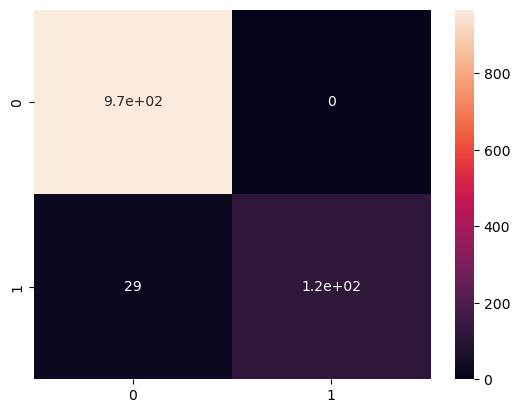

In [20]:
import seaborn as sns
sns.heatmap(cf_matrix, annot=True)

In [22]:
#precision

from sklearn.metrics import precision_score

#precision for training data predictions 
precision_train = precision_score(y_train, X_train_predict)
print("Training data precision : ", precision_train)


#precision for test data predictions 
precision_test = precision_score(y_test, X_test_predict)
print("Test data precision : ", precision_test)

Training data precision :  1.0
Test data precision :  1.0


In [25]:
#recall

from sklearn.metrics import recall_score

#recall for training data predictions 
recall_train = recall_score(y_train, X_train_predict)
print("Training data recall : ", recall_train)


#recall for test data predictions 
recall_test = recall_score(y_test, X_test_predict)
print("Test data recall : ", recall_test)

Training data recall :  0.8327759197324415
Test data recall :  0.8053691275167785


In [26]:
#F1-score

from sklearn.metrics import f1_score

#f1-score for training data predictions 
f1_score_train = f1_score(y_train, X_train_predict)
print("Training data F1-score : ", f1_score_train)


#f1-score for test data predictions 
f1_score_test = f1_score(y_test, X_test_predict)
print("Test data F1-score : ", f1_score_test)


Training data F1-score :  0.9087591240875912
Test data F1-score :  0.8921933085501859
